In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.decomposition import PCA

plt.style.use("default")

#Load the Dataset

In [7]:
X_train = np.load("../data/processed/X_train_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")

print("X_Train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

X_Train Shape: (5087, 3197)
y_train Shape: (5087,)


#Class Distribution

In [ ]:
unique, counts = np.unique(y_train, return_counts = True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count}")

#Note: Data is imbalanced.

Class 0: 5050
Class 1: 37


#Visualize Positive Samples

In [ ]:
#Finding stars containing planets

planet_indices = np.where(y_train == 1)[0]

print("Positive samples:", len(planet_indices))

Positive samples: 37


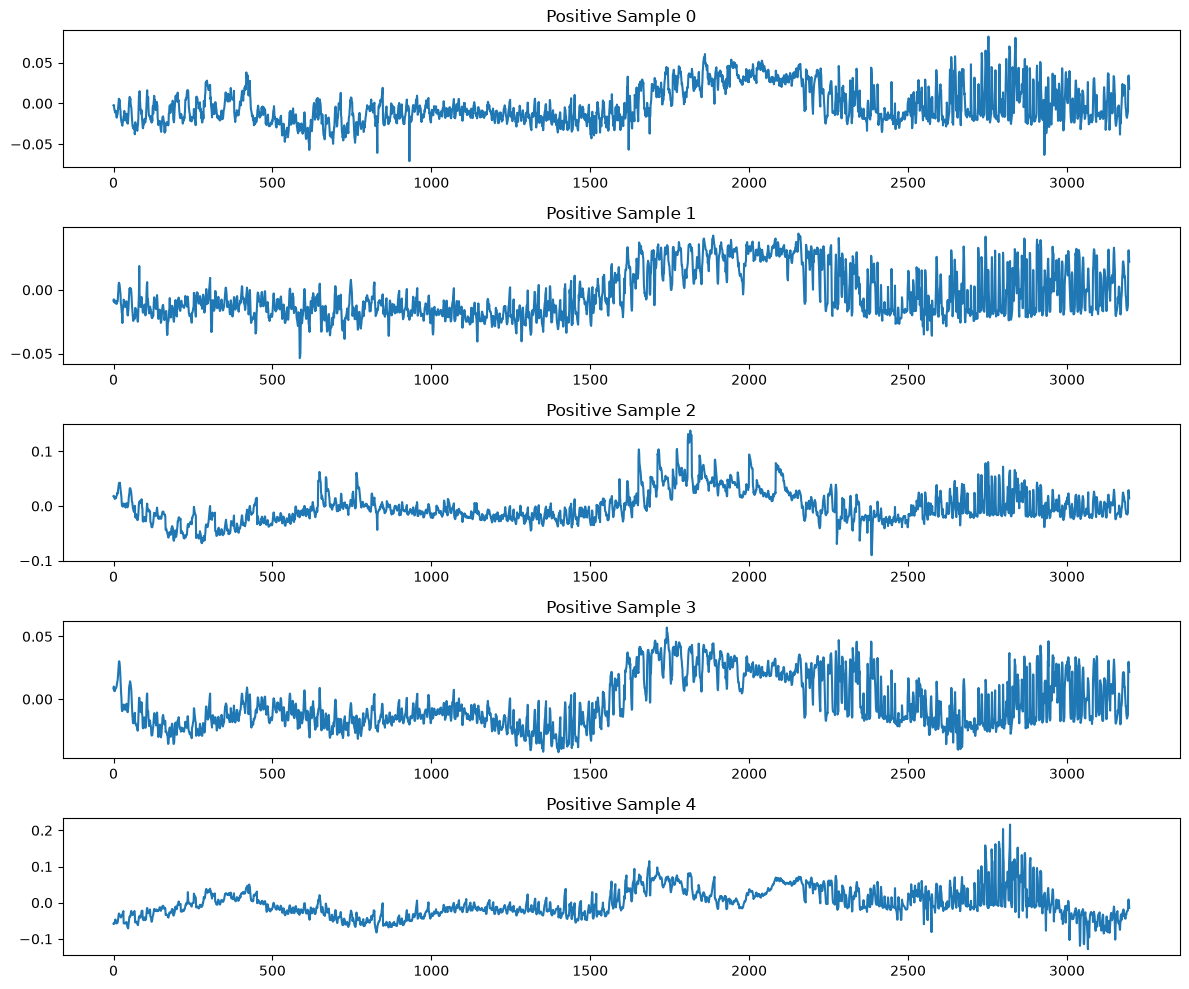

In [ ]:
#Plot first 5

fig, axes = plt.subplots(5, 1, figsize=(12,10))

for i in range(5):
    idx = planet_indices[i]

    axes[i].plot(X_train[idx])
    axes[i].set_title(f"Positive Sample {idx}")

plt.tight_layout()
plt.show()

#Observations:

1. Do transit dips appear? -> 
2. Are dips deep or shallow? ->
3. Are positive samples visually similar? -> 
4. How noisy are the signals? (Rate from 1-10) ->

#Need scatter plots of the light curve to answer the above questions. Should be broad as well. 

#Visualize Negative Samples

In [12]:
negative_indices = np.where(y_train == 0)[0]

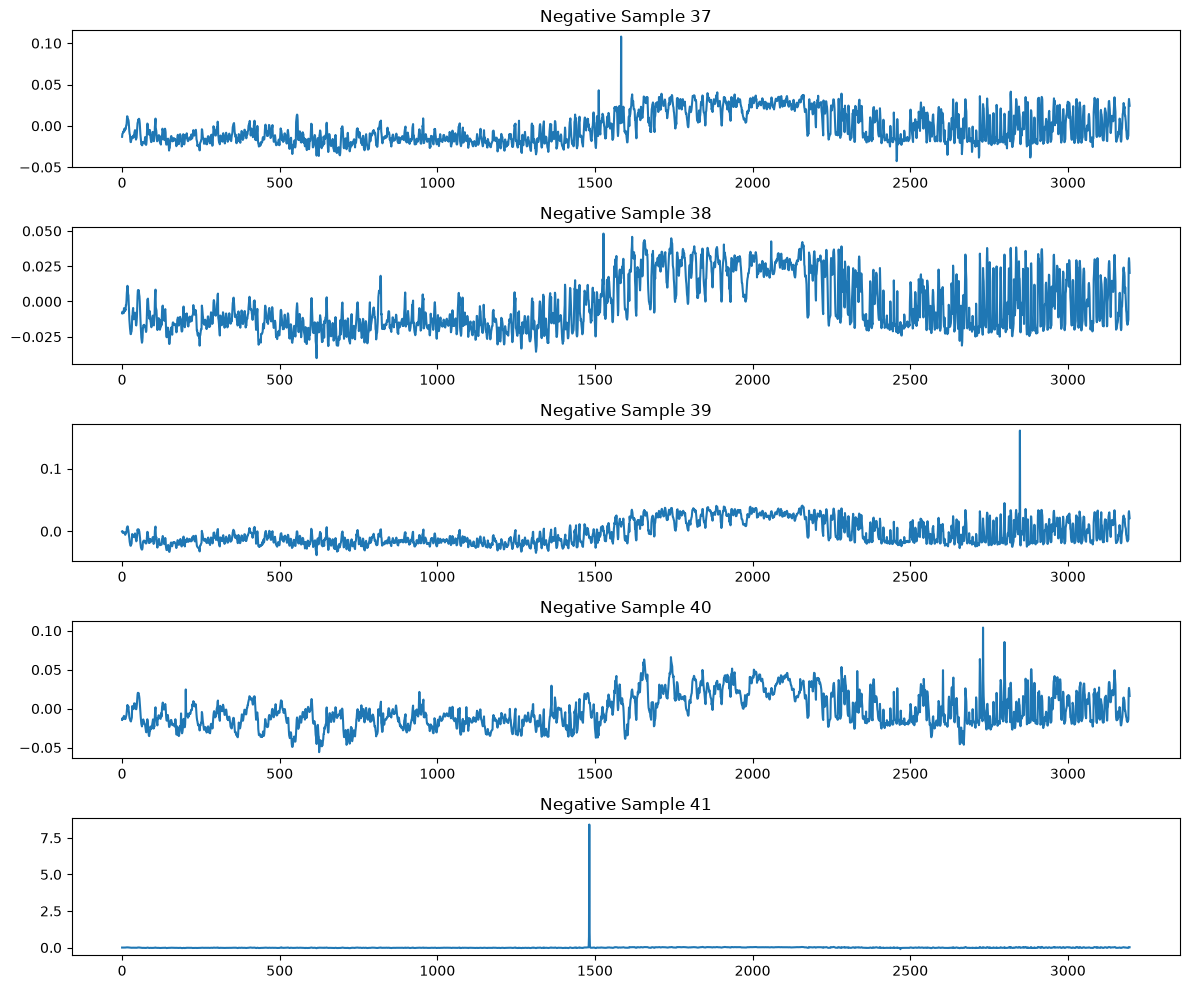

In [14]:
#Plot first 5

fig, axes = plt.subplots(5, 1, figsize=(12,10))

for i in range(5):
    idx = negative_indices[i]

    axes[i].plot(X_train[idx])
    axes[i].set_title(f"Negative Sample {idx}")

plt.tight_layout()
plt.show()

#Positive vs Negative Comparison

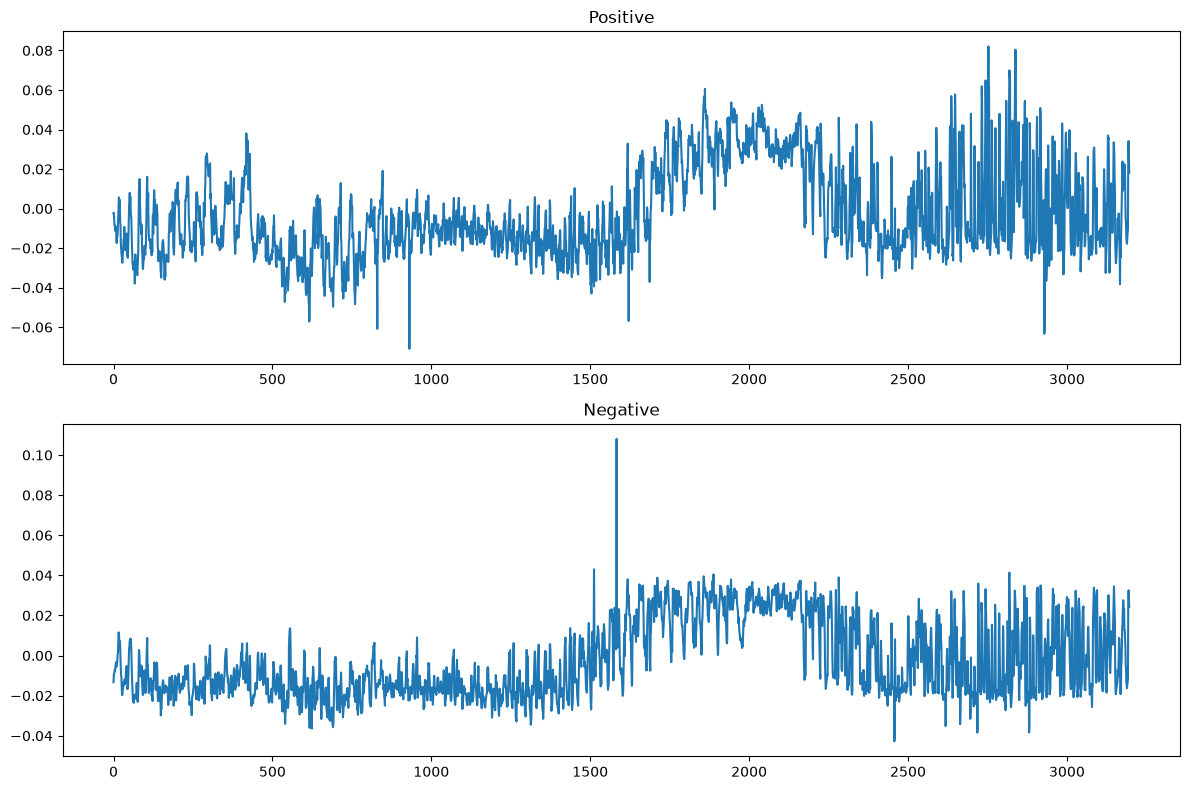

In [15]:
#Side by side comparison

fig, axes = plt.subplots(2, 1, figsize=(12,8))

axes[0].plot(X_train[planet_indices[0]])
axes[0].set_title("Positive")

axes[1].plot(X_train[negative_indices[0]])
axes[1].set_title("Negative")

plt.tight_layout()
plt.show()

#Average of the Light Curves

In [16]:
from matplotlib.pyplot import axis
positive_mean = X_train[y_train == 1].mean(axis=0)
negative_mean = X_train[y_train == 0].mean(axis=0)

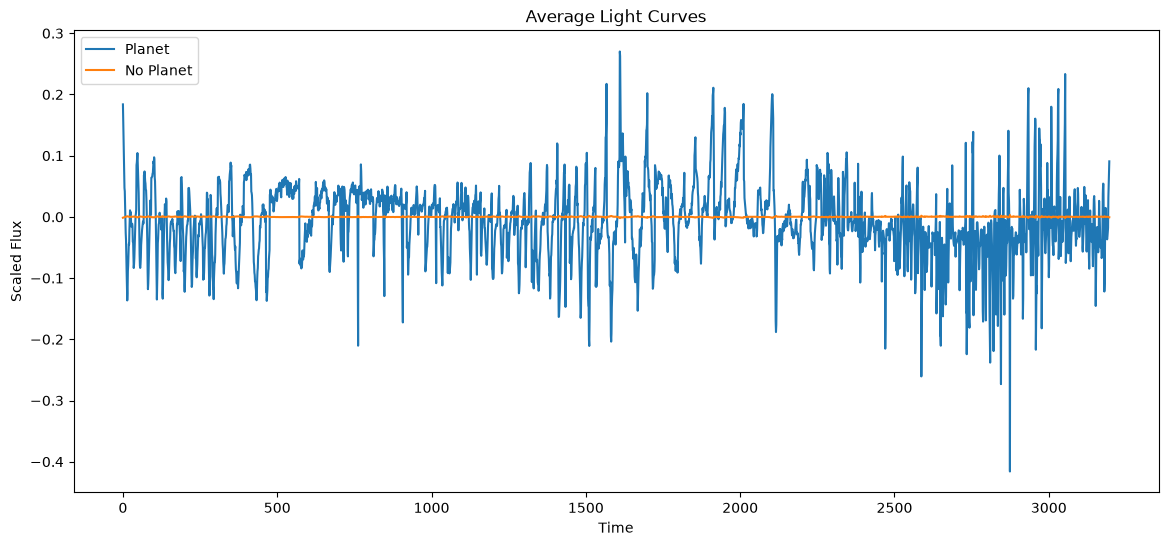

In [17]:
#Plot

plt.figure(figsize=(14,6))

plt.plot(positive_mean, label ="Planet")
plt.plot(negative_mean, label = "No Planet")

plt.legend()
plt.title("Average Light Curves")
plt.xlabel("Time")
plt.ylabel("Scaled Flux")

plt.show()

#Variability Analysis

In [18]:
#Compute Standard Deviation per star

std_per_star = X_train.std(axis=1)

In [19]:
#Seperate Classes

positive_std = std_per_star[y_train == 1]
negative_std = std_per_star[y_train == 0]

<function matplotlib.pyplot.show(close=None, block=None)>

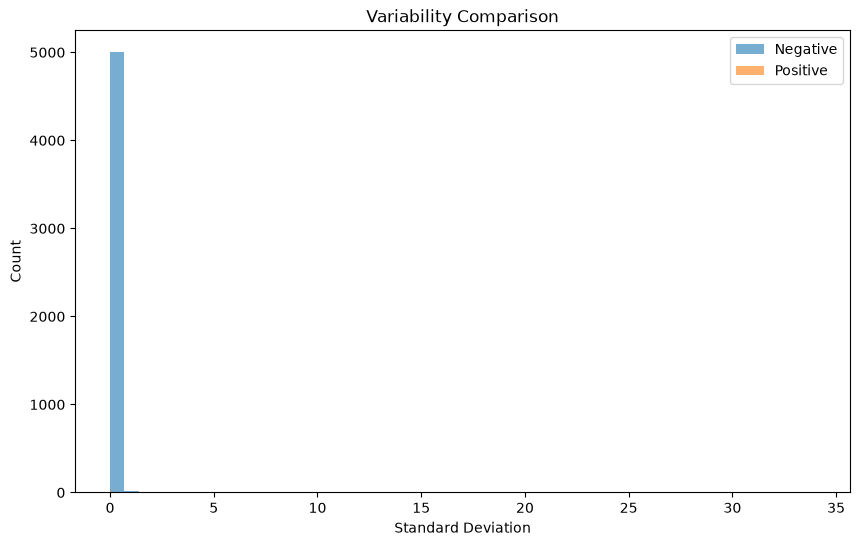

In [21]:
#Plot

plt.figure(figsize=(10,6))

plt.hist(
    negative_std,
    bins = 50,
    alpha = 0.6,
    label = "Negative"
)

plt.hist(
    positive_std,
    bins = 50,
    alpha = 0.6,
    label = "Positive"
)

plt.legend()
plt.title("Variability Comparison")
plt.xlabel("Standard Deviation")
plt.ylabel("Count")
plt.show

In [22]:
#Statistics
print("Positive mean std:", positive_std.mean())

print("Negative mean std:", negative_std.mean())

Positive mean std: 0.09182508031362457
Negative mean std: 0.08687683474180302


#PCA Visualization (Dimensionality Reduction)

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

print(X_pca.shape)

(5087, 2)


In [26]:
print(X_pca.shape)
print(y_train.shape)

(5087, 2)
(5087,)


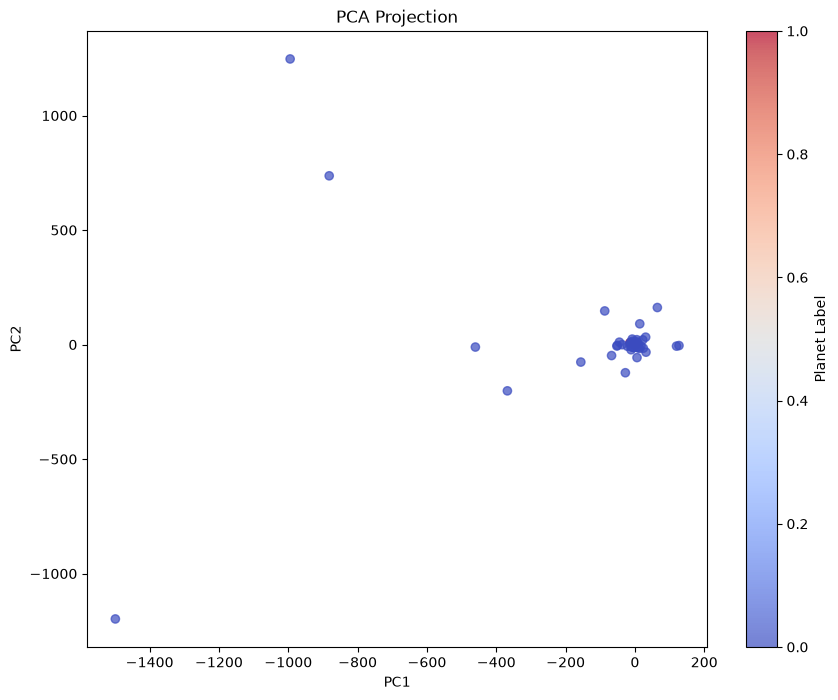

In [27]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Planet Label")

plt.show()

In [28]:
print(pca.explained_variance_ratio_)

[0.27373539 0.22536219]


In [33]:
print(X_pca.shape)
print(len(X_pca))
print(np.unique(y_train, return_counts=True))

(5087, 2)
5087
(array([0, 1]), array([5050,   37]))


###PCA Analysis

PCA was applied to reduce the original 3197-dimensional light curve data into two principal components for visualization and exploratory analysis.

##Dataset Overview

- Total Stars: 5087
- Positive Samples (Planet): 37
- Negative Samples (No Planet): 5050

##Explained Variance

- PC1 explained **27.37%** of the total variance.
- PC2 explained **22.54%** of the total variance.
- Together, the first two principal components retained approximately **49.91%** of the dataset information.

##Observations

1. Most samples are concentrated near the origin, indicating similar overall signal structures.
2. Several outliers are present, suggesting stars with unusual light curve behaviour and unsually high variability.
3. No obvious class seperation is visible in the PCA projection.
4. The dataset is highly imbalanced, containing only 37 positive samples compared to 5050 negative samples. This imbalance makes the visual class seperation difficult and may affect future model training.
5. Although PCA retained nearly 50% of the total variance, the reduced two-dimensional representation does not reveal an obvious clustering structure for the positive class.

##Interpretation

The PCA results suggest that the exoplanet signals are not linearly seperable when compressed into only two dimensions. Therefore, successful exoplanet detection will likely require:
- Statistical feature engineering
- Domain-specific signal features
- Non-linear machine learning models
- Careful handling of class imbalance

##Conclusion
PCA provided a useful overview of the dataset structure and revealed several outliers, but it did not expose a clear boundary between classes. This indicated that more informative engineered features will be required before training classification models.

### Next Phase

Phase 4 will focus on extracting meaningful statistical features from the raw light curves and constructing a compact machine learning dataset for classification.

##Feature Engineering Ideas

Based on the exploratory analysis, the following features may be useful for exoplanet detection:

| Feature | Potential Usefulness | Reason |
|----------|----------|----------|
| Mean Flux | Moderate | Represents overall brightness level |
| Standard Deviation | High | Measures signal variability |
| Minimum Flux | High | Captures transit dips |
| Maximum Flux | Low-Moderate | May capture unusual peaks |
| Flux Range | High | Measures overall fluctuation magnitude |
| Skewness | Moderate | Detects asymmetry in flux distribution |
| Kurtosis | Moderate | Detects extreme peaks and dips |
| PCA Components | Moderate | Compressed representation of signal patterns |
| FFT Peaks | Potentially Useful | May capture periodic transit behavior |

##Proposed Features for Phase 4

1. Mean Flux
2. Standard Deviation
3. Minimum Flux
4. Maximum Flux
5. Flux Range
6. Skewness
7. Kurtosis

Additional frequency-domain features may be explored later using FFT analysis.